# **Rep. 3. Checkpoint 1. Valuación de opciones europeas**

### Paola A. Figueroa Álvarez
###  10/03/2026

## **Objetivo**
Explorar cómo cambian las simulaciones de precios cuando se modifican los parámetros del modelo.

Deberás variar un parámetro a la vez, manteniendo los demás constantes (ceteris paribus) para entender cómo cada variable afecta el comportamiento del activo y el valor de la opción.

Usando el mismo activo que usamos, con los mismos parámetros usados en clase, también disponibles en Notion.

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# Parámetros iniciales
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

# Definimos parámetrtos
S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años
K = 580   
num_simulations = 10000

print("Parámetros de la simulación:")
print(f"Precio spot (S0): {S0}")
print(f"Tasa libre de riesgo (r): {r}")
print(f"Tiempo al vencimiento (T): {T}")
print(f"Strike (K): {K}")
print(f"Número de simulaciones: {num_simulations}")

[*********************100%***********************]  1 of 1 completed

Parámetros de la simulación:
Precio spot (S0): 678.27001953125
Tasa libre de riesgo (r): 0.08
Tiempo al vencimiento (T): 0.273972602739726
Strike (K): 580
Número de simulaciones: 10000


----

## **Parte 1**
Modificar únicamente σ.

- Probar con:

    - σ = 0.01
    - σ = 0.10
    - σ = 0.20
    - σ = 0.40
- Graficar:

    - Distribución del precio Spot final en los 4 escenarios
- Crear:

    - Crear una tabla con el valor de la call para cada escenario

    - Crear una tabla con el valor de la put para cada escenario-

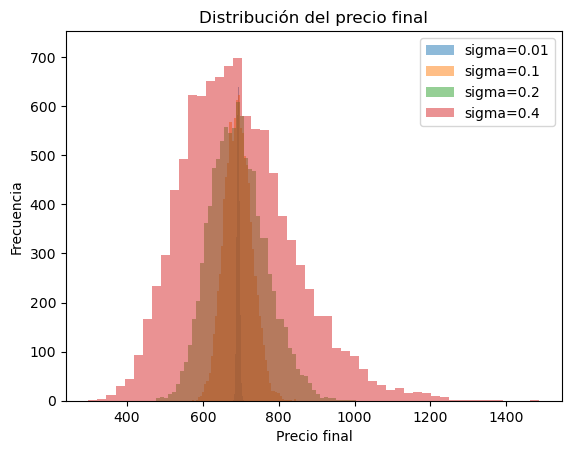

In [3]:
sigmas = [0.01, 0.10, 0.20, 0.40]
results = []

for s in sigmas:
    Z = np.random.normal(0,1,num_simulations)
    ST = S0 * np.exp((r - 0.5*s**2)*T + s*np.sqrt(T)*Z)
    
    call = np.maximum(ST-K,0)
    put = np.maximum(K-ST,0)
    
    call_value = np.exp(-r*T)*np.mean(call)
    put_value = np.exp(-r*T)*np.mean(put)
    
    results.append([s,call_value,put_value])
    
    plt.hist(ST, bins=50, alpha=0.5, label=f"sigma={s}")

plt.legend()
plt.title("Distribución del precio final")
plt.xlabel("Precio final")
plt.ylabel("Frecuencia")
plt.show()



In [4]:
df_vol = pd.DataFrame(results, columns=["Sigma","Call","Put"])
df_vol

,Sigma,Call,Put
0,0.01,110.856195,0.000000
1,0.10,110.566204,0.001711
2,0.20,111.526114,1.119459
3,0.40,123.337821,14.123664


### **Respuestas**

- ¿Qué sucede con la dispersión de las trayectorias?
    - A mayor volatilidad, las trayectorias del precio se vuelven más dispersas, generando precios finales más alejados del valor inicial.

- ¿Cómo cambia la distribución de precios?
    - La distribución se vuelve más amplia y con mayor variabilidad conforme aumenta σ.

- ¿Aumenta o disminuye el valor de la opción conforme aumenta σ?
    - El valor de la call y la put aumenta cuando aumenta la volatilidad, ya que existe mayor probabilidad de terminar in the money.

----

## **Actividad 2 — Tiempo al vencimiento**
Modificar únicamente T.

- Probar con:

    - T = 30 días
    - T = 100 días
    - T = 1 año
- Graficar nuevamente:

    - 1- Distribución final del precio Spot

- Crear nuevamente

    - Crear una tabla con el valor de la call para cada escenario

    - Crear una tabla con el valor de la put para cada escenario

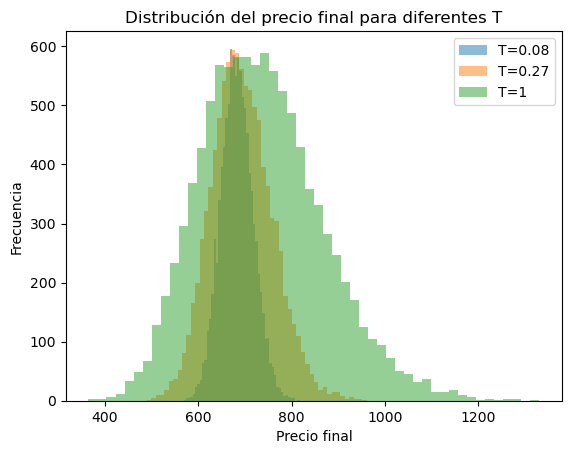

In [5]:
Ts = [30/365, 100/365, 1]

results_T = []

for t in Ts:
    
    Z = np.random.normal(0,1,num_simulations)
    
    ST = S0 * np.exp((r - 0.5*sigma**2)*t + sigma*np.sqrt(t)*Z)
    
    call = np.maximum(ST-K,0)
    put = np.maximum(K-ST,0)
    
    call_value = np.exp(-r*t)*np.mean(call)
    put_value = np.exp(-r*t)*np.mean(put)
    
    results_T.append([t,call_value,put_value])
    
    plt.hist(ST, bins=50, alpha=0.5, label=f"T={round(t,2)}")

plt.legend()
plt.title("Distribución del precio final para diferentes T")
plt.xlabel("Precio final")
plt.ylabel("Frecuencia")
plt.show()


In [6]:
df_T = pd.DataFrame(results_T, columns=["T","Call","Put"])
df_T


,T,Call,Put
0,0.082192,102.266081,0.003170
1,0.273973,111.590363,0.661078
2,1.000000,147.818699,4.474581


## **Respuestas**

- ¿Cómo cambia la distribución final del precio al aumentar T?
    - Al aumentar el tiempo al vencimiento, la distribución del precio final se vuelve más dispersa, ya que el activo tiene más tiempo para fluctuar.

-  ¿Aumenta o disminuye el valor de la opción conforme aumenta T?
    - Generalmente el valor de las opciones aumenta cuando aumenta el tiempo al vencimiento, porque existe más oportunidad de que la opción termine in the money.

-----

## **Actividad 3 — Precio de ejercicio**
Modificar únicamente K.

- Probar con:

    - K = S0 * 0.70
    - K = S0 * 0.90
    - K = S0
    - K = S0 * 1.10
    - K = S0 * 1.30
- Graficar nuevamente:

    - 1- Distribución final del precio Spot
- Crear:

    - Crear una tabla con el valor de la call para cada escenario

    - rear una tabla con el valor de la put para cada escenario

In [7]:
Ks = [S0*0.70, S0*0.90, S0, S0*1.10, S0*1.30]

results_K = []

for k in Ks:
    
    Z = np.random.normal(0,1,num_simulations)
    
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    call = np.maximum(ST-k,0)
    put = np.maximum(k-ST,0)
    
    call_value = np.exp(-r*T)*np.mean(call)
    put_value = np.exp(-r*T)*np.mean(put)
    
    results_K.append([k,call_value,put_value])


In [8]:
df_K = pd.DataFrame(results_K, columns=["Strike","Call","Put"])
df_K

,Strike,Call,Put
0,474.789014,213.751804,0.000000
1,610.443018,83.314414,2.445606
2,678.270020,32.701265,18.216352
3,746.097021,7.654755,58.785691
4,881.751025,0.120959,184.165838


## **Respuestas**

- ¿Aumenta o disminuye el valor de la opción conforme aumenta K?

    - El valor de la call disminuye cuando aumenta el strike. Por el otro lado, el valor de la put aumenta cuando aumenta el strike.

- ¿Qué ocurre cuando el strike es muy alto o muy bajo?
    - Strike muy bajo: el call tiene un valor alto porque está profundamente in the money.
    - Strike muy alto: el call tiene valor cercano a cero porque es poco probable que el precio final supere ese nivel.

----

## **Actividad 4 — Tasa libre de riesgo**
Modificar únicamente r.

- Probar con:

    - r = 0.01
    - r = 0.05
    - r = 0.10
- Graficar:
    - 1- Distribución final del precio Spot

- Crear:
    - Crear una tabla con el valor de la call para cada escenario
    - Crear una tabla con el valor de la put para cada escenario


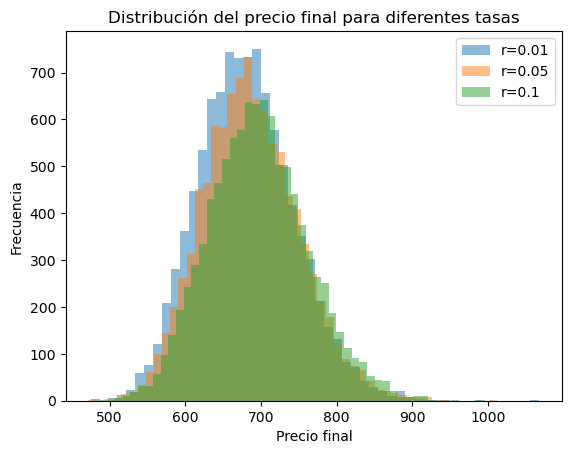

In [9]:
rates = [0.01,0.05,0.10]

results_r = []

for rate in rates:
    
    Z = np.random.normal(0,1,num_simulations)
    
    ST = S0 * np.exp((rate - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    call = np.maximum(ST-K,0)
    put = np.maximum(K-ST,0)
    
    call_value = np.exp(-rate*T)*np.mean(call)
    put_value = np.exp(-rate*T)*np.mean(put)
    
    results_r.append([rate,call_value,put_value])
    
    plt.hist(ST, bins=50, alpha=0.5, label=f"r={rate}")

plt.legend()
plt.title("Distribución del precio final para diferentes tasas")
plt.xlabel("Precio final")
plt.ylabel("Frecuencia")
plt.show()


In [10]:
df_r = pd.DataFrame(results_r, columns=["Tasa","Call","Put"])
df_r


,Tasa,Call,Put
0,0.01,101.029544,0.978260
1,0.05,105.793237,0.774559
2,0.10,113.995942,0.569090


## **Respuestas**

- ¿Cómo cambia el crecimiento esperado del precio del activo?
    - Cuando aumenta la tasa libre de riesgo, el crecimiento esperado del precio del activo aumenta dentro del modelo de movimiento geométrico browniano.

- ¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?
    - El valor del call aumenta, ya que el precio esperado del activo tiende a ser mayor.

- ¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?
    - El valor del put disminuye, porque un mayor crecimiento esperado del activo reduce la probabilidad de terminar in the money.